# Часть Б: разбор ошибок

Показываются реальные предсказания выбранной модели на validation. Зелёные рамки — TP, красные — FP, жёлтые — пропуски (FN, рамки разметки). Совпадение определяется по классу и IoU≥0.5, одно предсказание на один объект.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "configs/b/evaluation.yaml").exists())
validation = ROOT / "reports/b/validation"
report = json.loads((validation / "comparison.json").read_text(encoding="utf-8"))
assert report["split"] == "val" and not report["test_evaluated"]


In [2]:
winner = report["selection"]["name"]
row = next(row for row in report["models"] if row["name"] == winner)
display(pd.Series(row["operating_point"]))
records = json.loads((validation / winner / "per_image.json").read_text(encoding="utf-8"))
counts = pd.DataFrame([{k: r[k] for k in ["image", "tp", "fp", "fn"]} for r in records])
display(counts.sort_values(["fn", "fp"], ascending=False).head(15))


conf           0.400000
tp           389.000000
fp           120.000000
fn           194.000000
precision      0.764244
recall         0.667238
f1             0.712454
dtype: float64

,image,tp,fp,fn
14,images/val/image_00000148.jpg,3,1,20
134,images/val/image_00000690.jpg,9,5,10
5,images/val/image_00000127.jpg,5,8,8
4,images/val/image_00000126.jpg,5,3,7
136,images/val/image_00000692.jpg,11,3,7
131,images/val/image_00000687.jpg,3,0,7
139,images/val/image_00000695.jpg,4,4,5
98,images/val/image_00000471.jpg,4,2,5
149,images/val/image_00000705.jpg,5,2,5
47,images/val/image_00000420.jpg,2,1,5


## Верные обнаружения

images/val/image_00000096.jpg

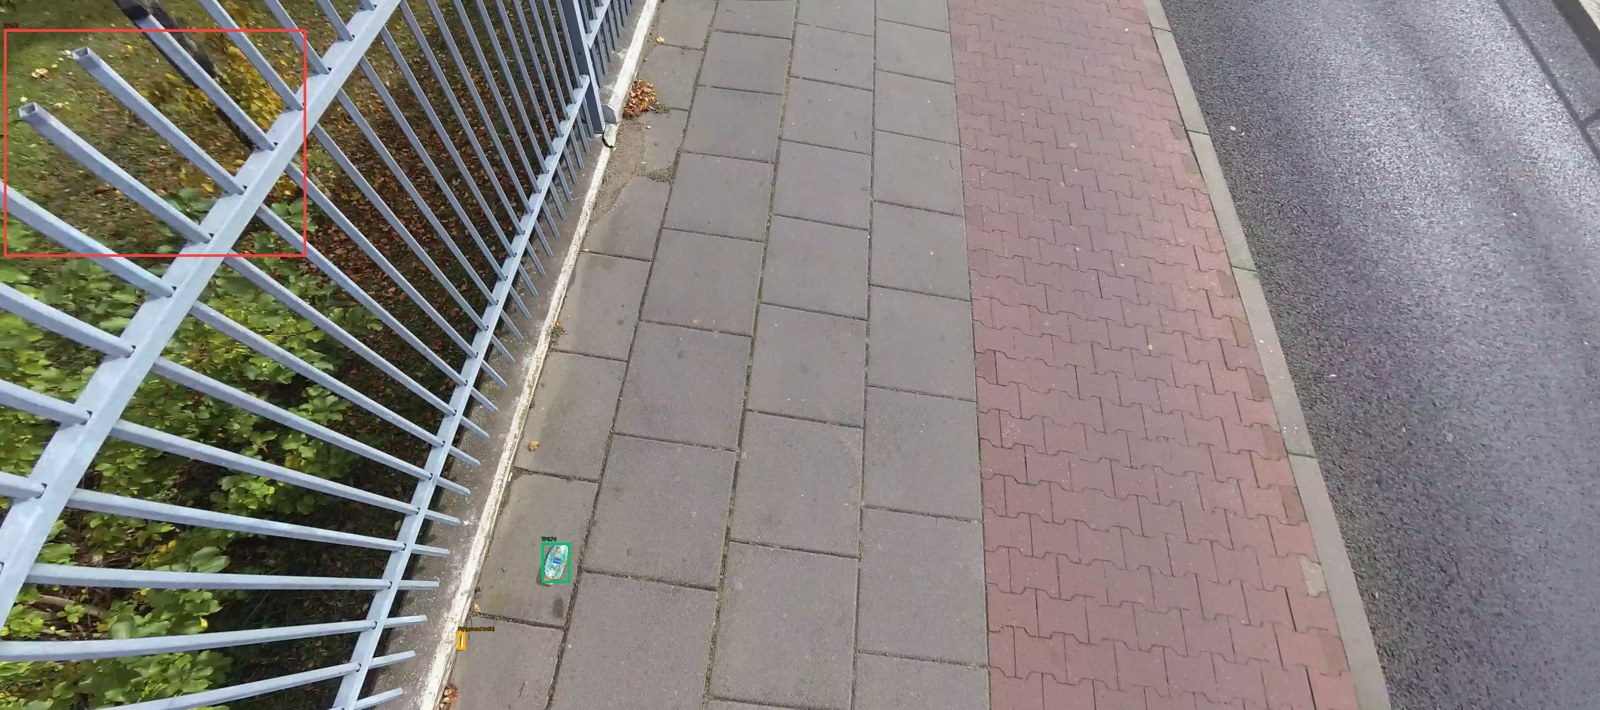

images/val/image_00000107.jpg

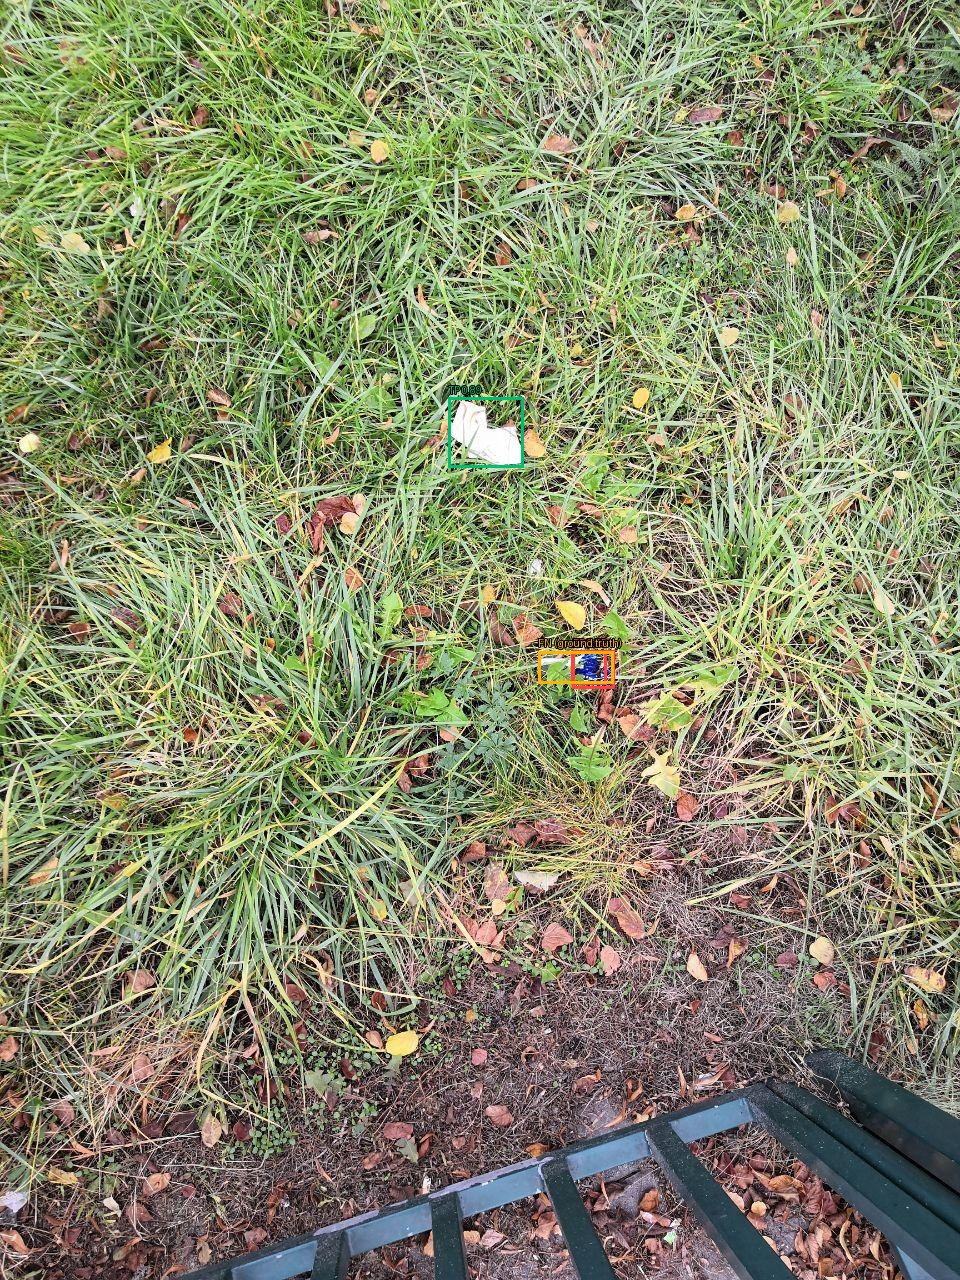

images/val/image_00000126.jpg

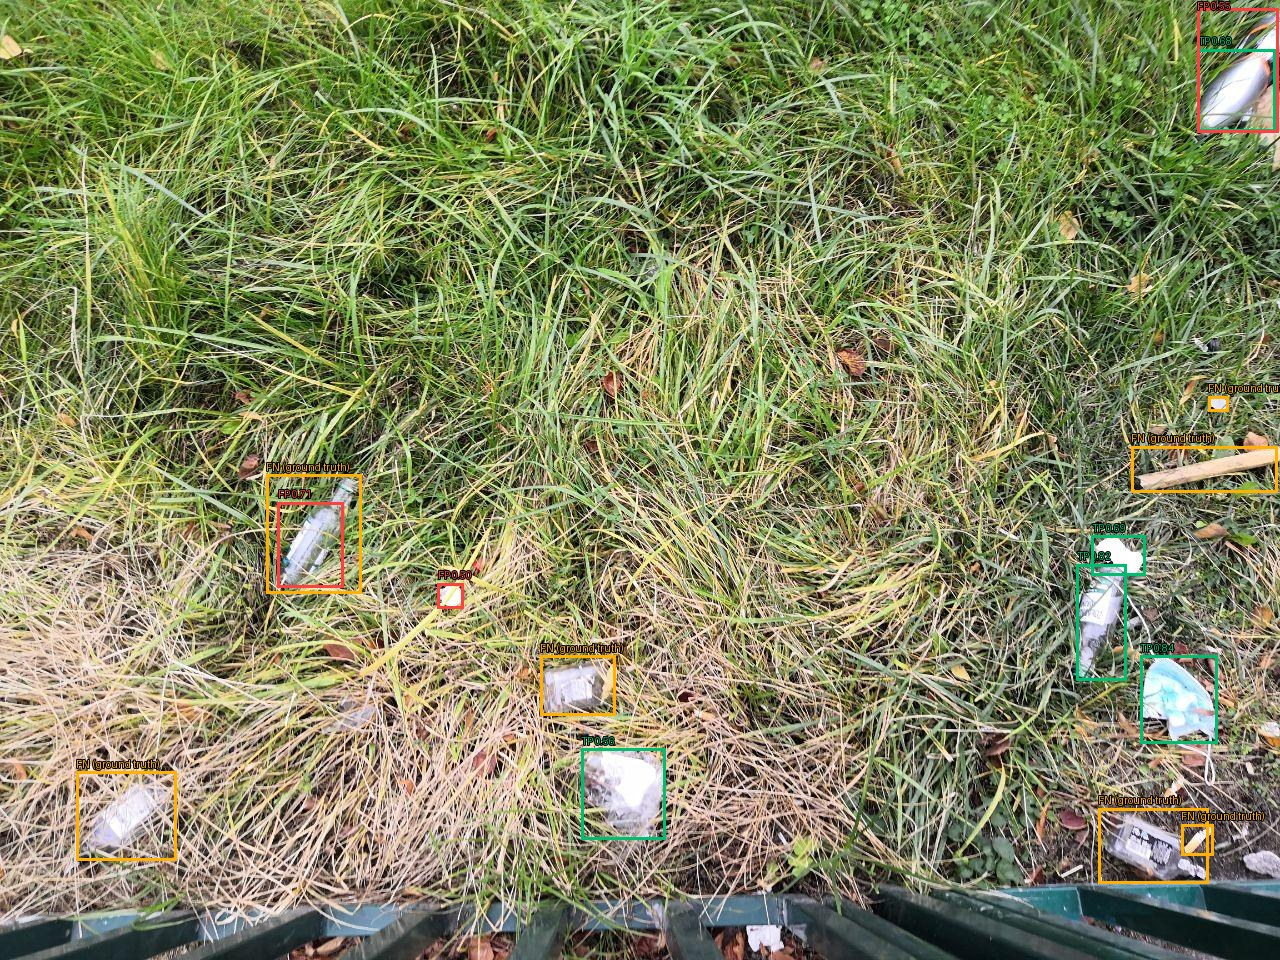

## Пропущенные объекты

images/val/image_00000096.jpg

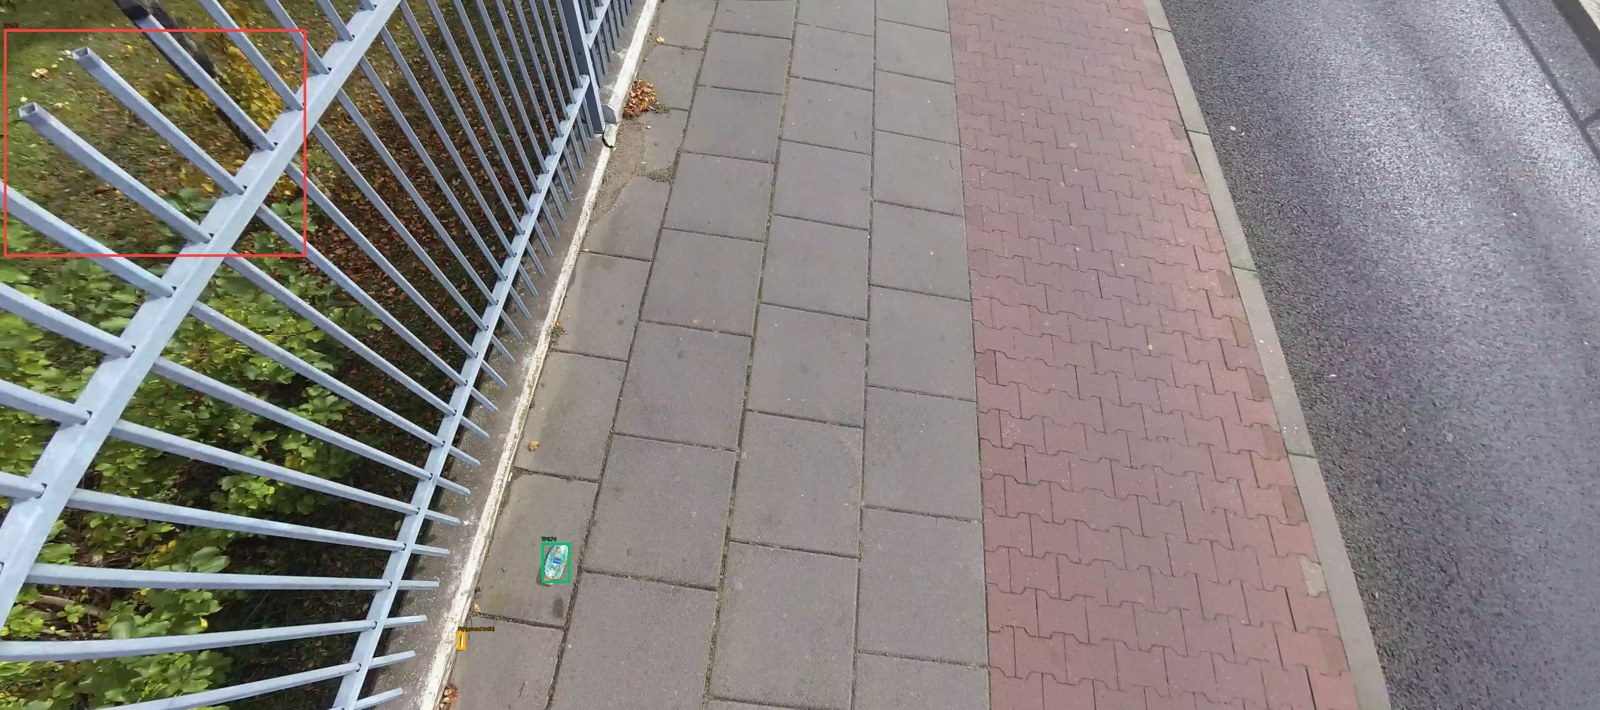

images/val/image_00000098.jpg

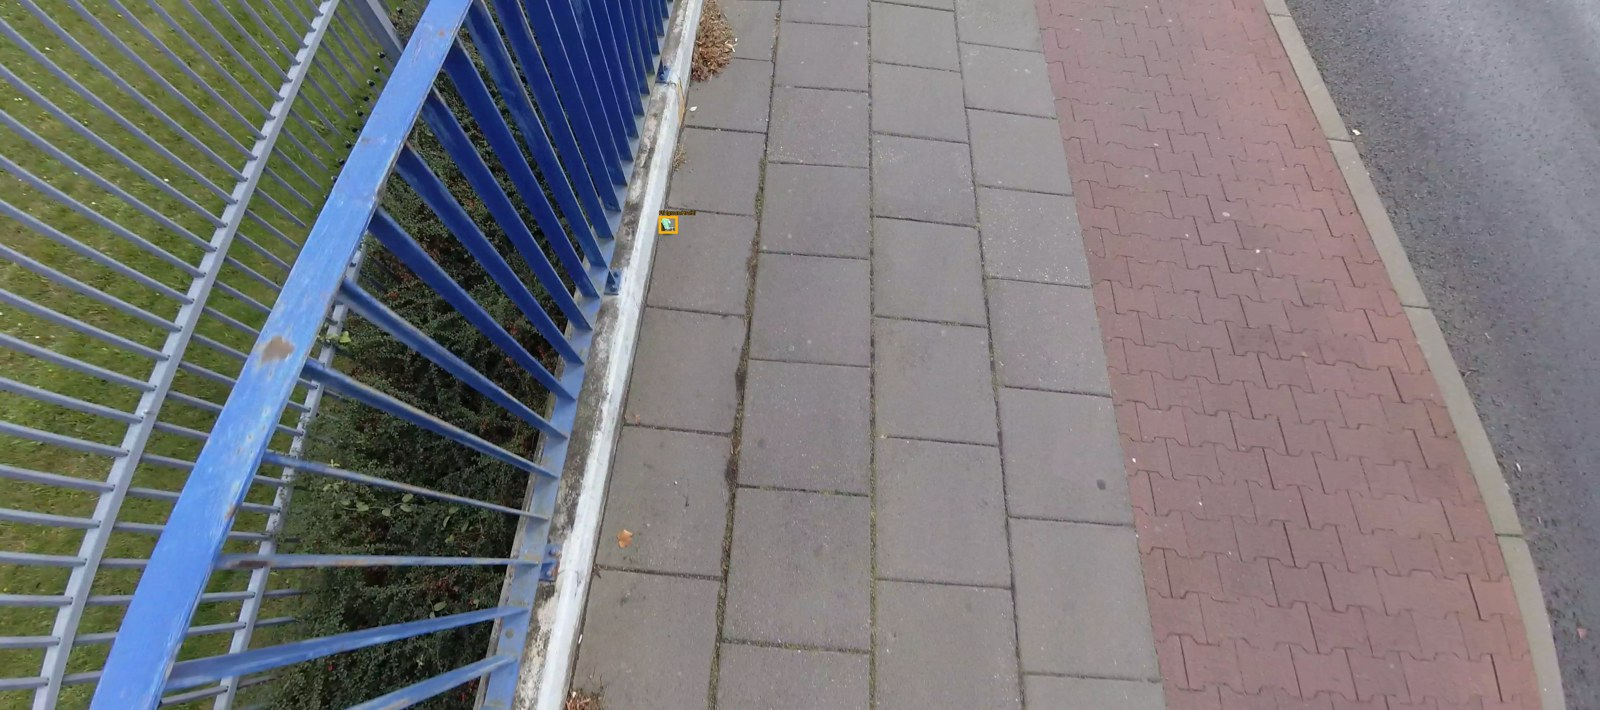

images/val/image_00000107.jpg

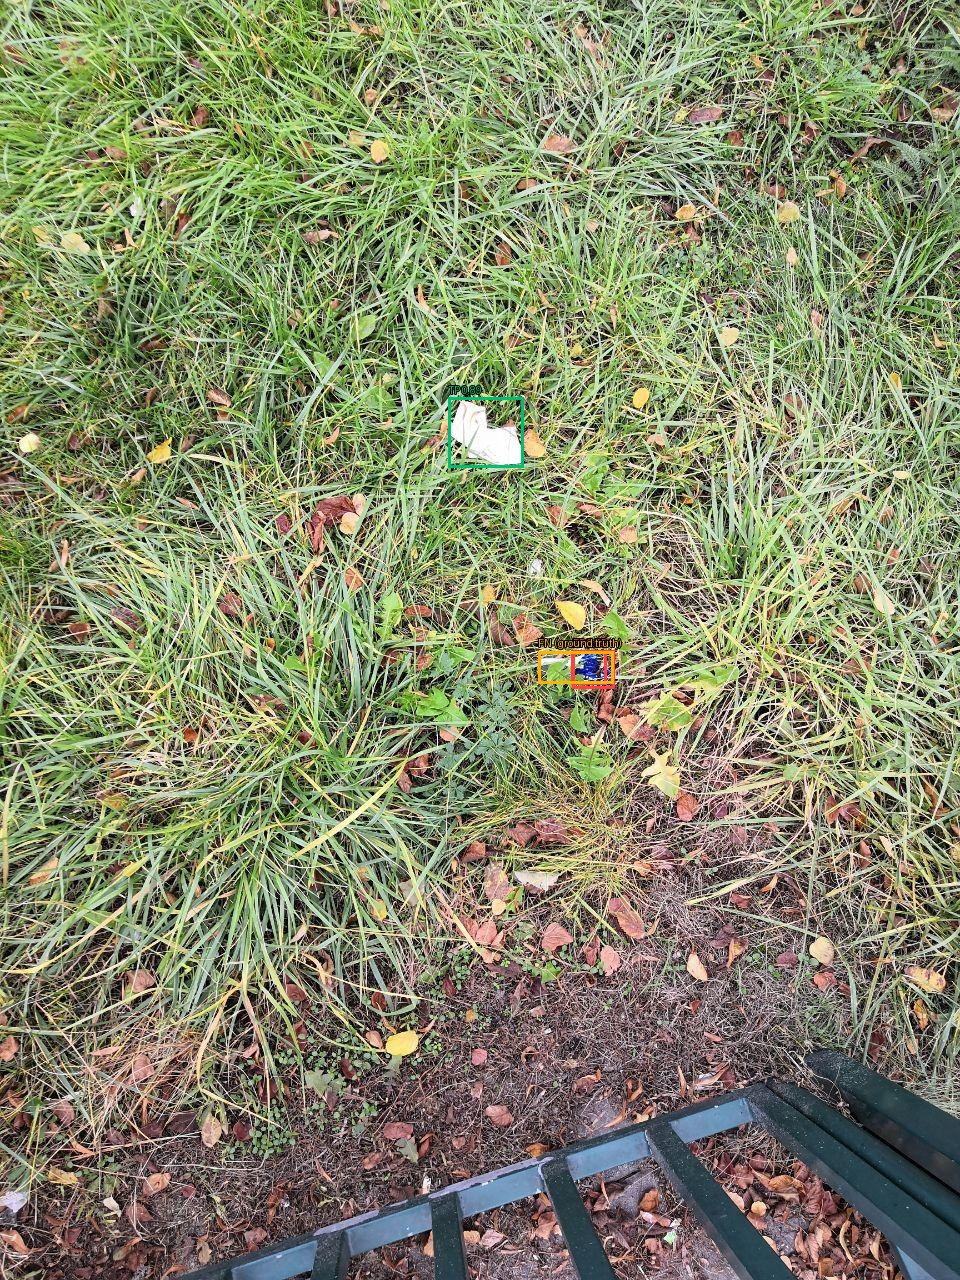

## Ложные обнаружения

images/val/image_00000096.jpg

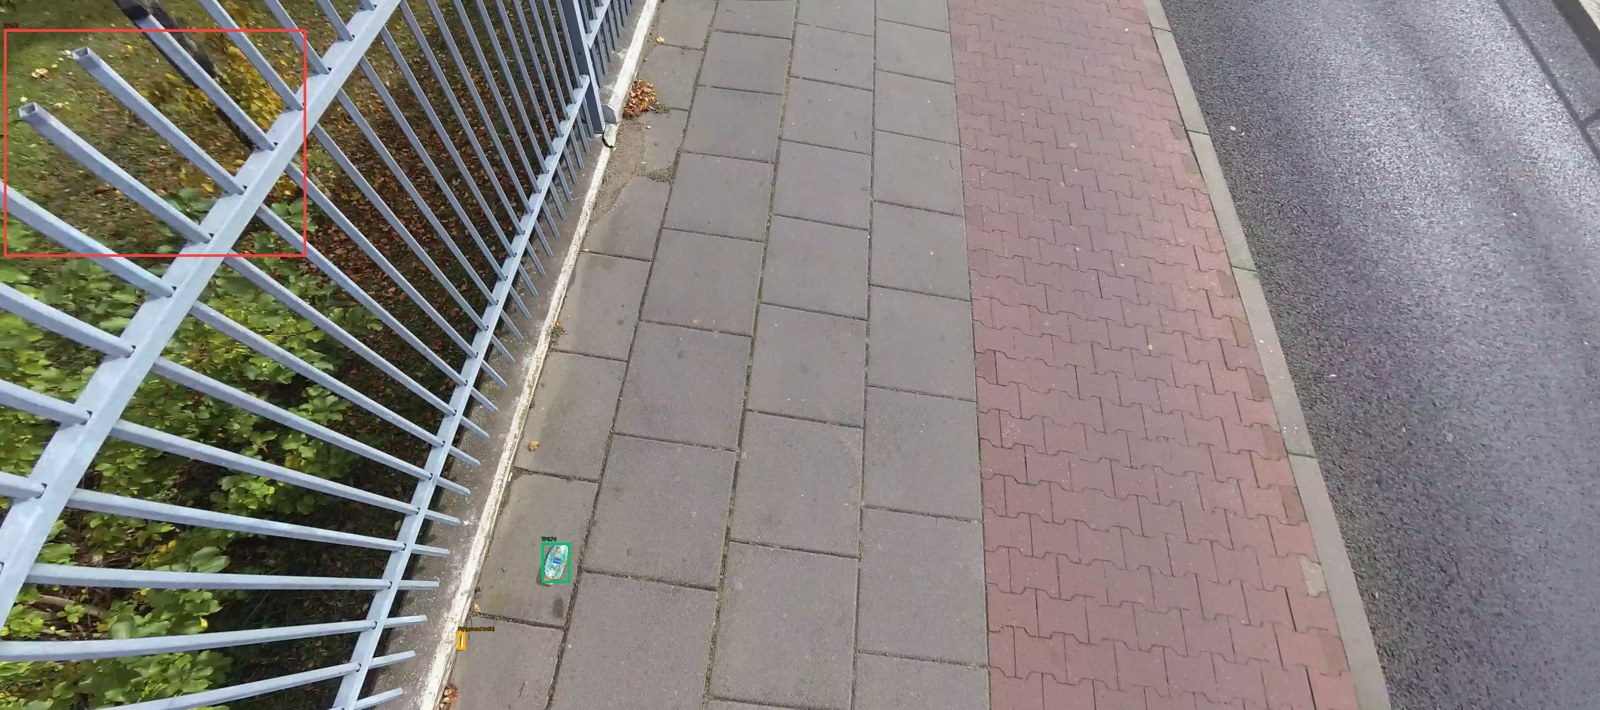

images/val/image_00000107.jpg

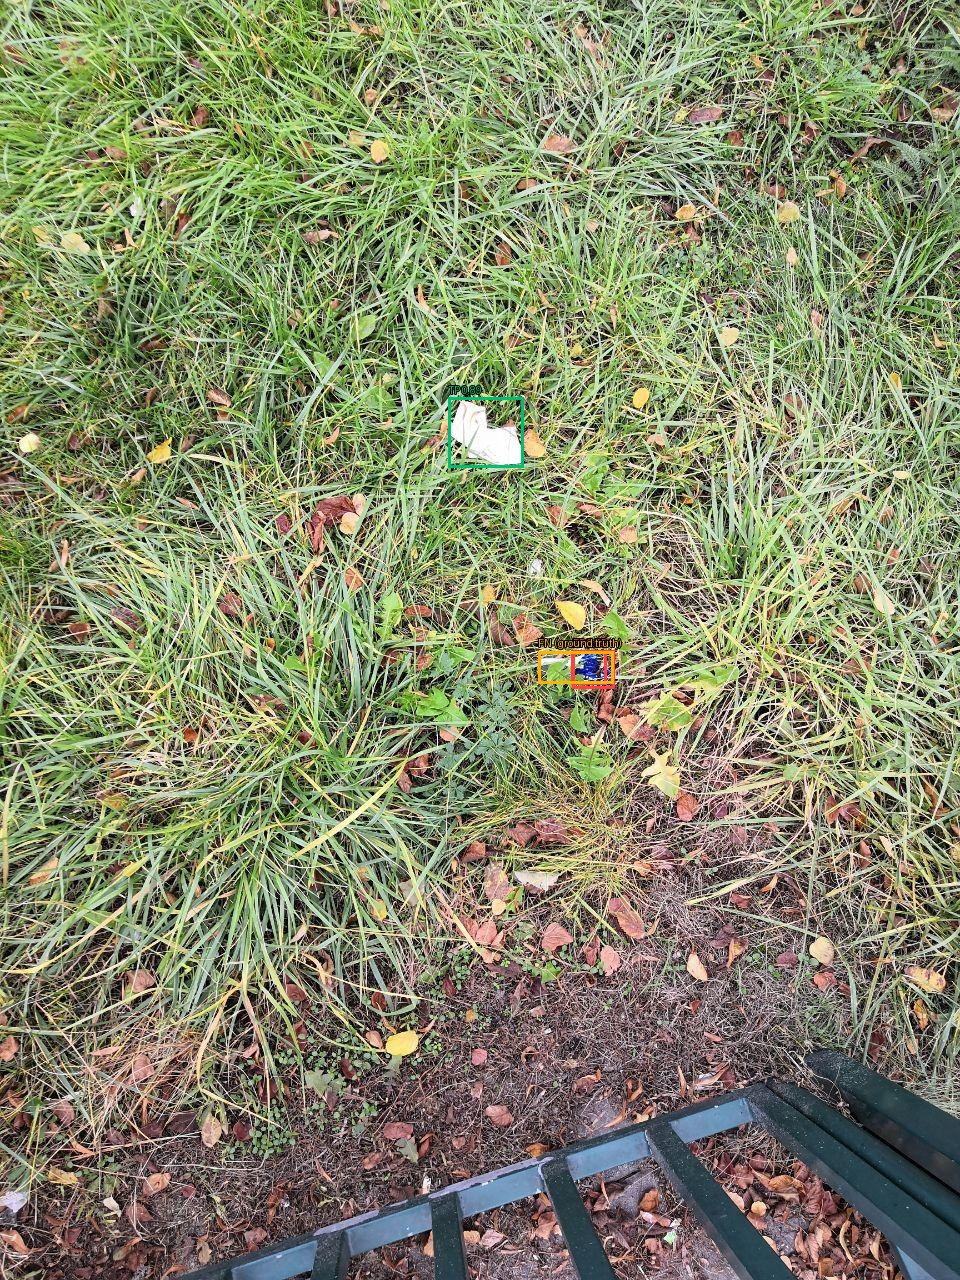

images/val/image_00000115.jpg

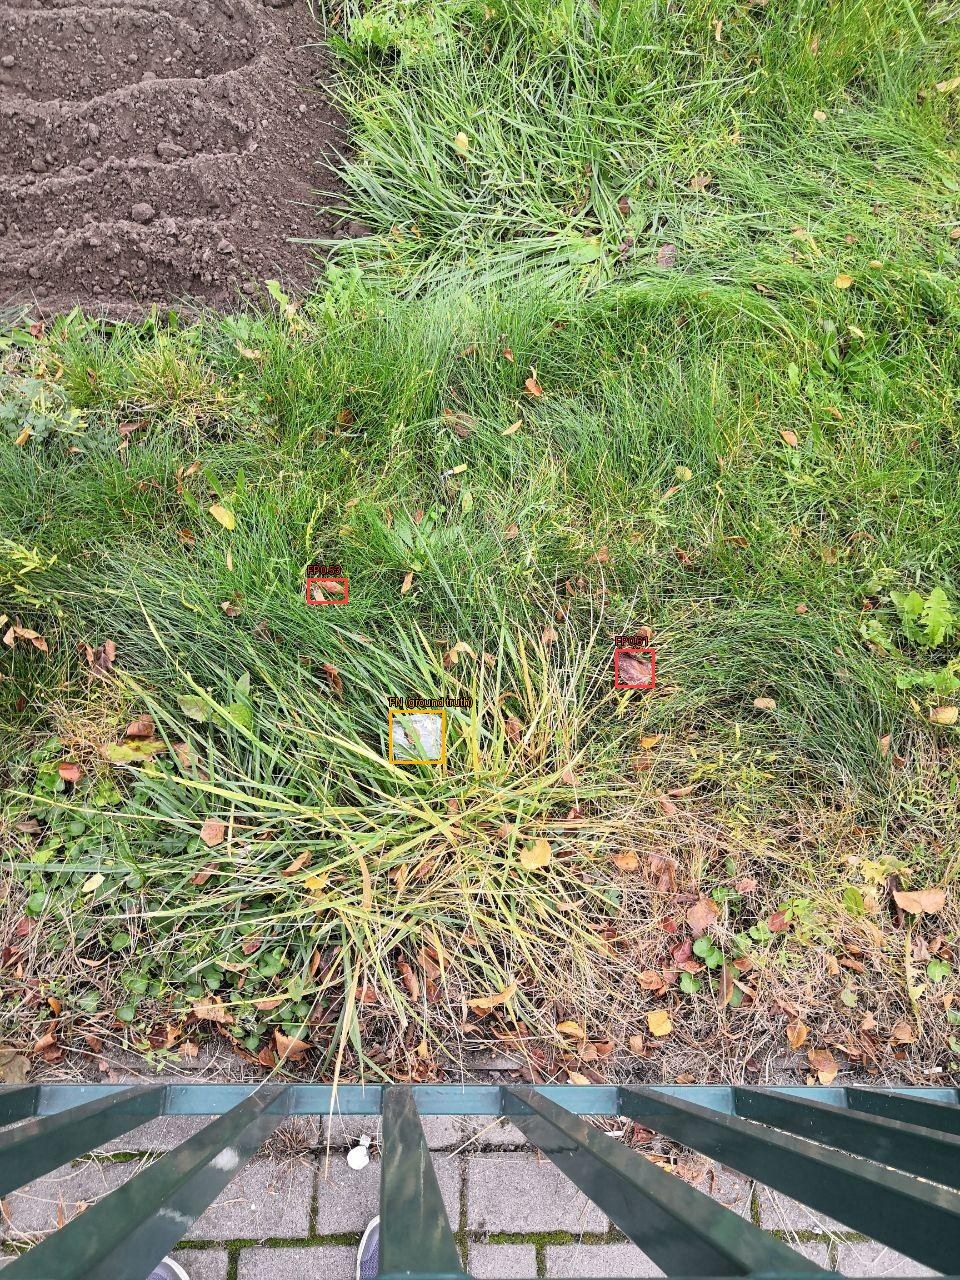

In [3]:
for kind, title in [("tp", "Верные обнаружения"), ("fn", "Пропущенные объекты"), ("fp", "Ложные обнаружения")]:
    display(Markdown("## " + title))
    for example in row["examples"][kind]:
        display(Markdown(example["image"]))
        display(Image(filename=str(validation / winner / example["file"]), width=1000))
    if not row["examples"][kind]:
        display(Markdown("Таких случаев при зафиксированном пороге нет."))


## Как интерпретировать ошибки

Проверьте размер объектов, фон, перекрытие и полноту разметки. Один кадр может содержать все типы ошибок. FP здесь определён относительно имеющихся меток; это не измерение на независимых чистых сценах. Жёлтая рамка не является предсказанием модели. Повышение порога может убрать FP, но увеличивает FN. Неточно локализованная рамка может дать FP и FN одновременно.

In [4]:
breakdown = json.loads((validation / "error_breakdown.json").read_text(encoding="utf-8"))
display(pd.DataFrame(breakdown["size_bins"]).T)
display(pd.Series(breakdown["false_positive_overlap"]))


,objects,found,recall
short_side_lt_8px,159.0,71.0,0.446541
short_side_8_to_16px,300.0,228.0,0.760000
short_side_ge_16px,124.0,90.0,0.725806


overlap_lt_0.1                      82
overlap_0.1_to_match_iou            33
duplicate_or_assignment_conflict     5
dtype: int64

In [5]:
display(pd.DataFrame(row["confidence_curve"])[["conf", "tp", "fp", "fn", "precision", "recall", "f1"]].round(4))


,conf,tp,fp,fn,precision,recall,f1
0,0.05,488,959,95,0.3372,0.8370,0.4808
1,0.10,477,591,106,0.4466,0.8182,0.5778
2,0.15,463,436,120,0.5150,0.7942,0.6248
3,0.20,442,338,141,0.5667,0.7581,0.6486
4,0.25,429,264,154,0.6190,0.7358,0.6724
5,0.30,419,204,164,0.6726,0.7187,0.6949
6,0.35,406,158,177,0.7199,0.6964,0.7079
7,0.40,389,120,194,0.7642,0.6672,0.7125
8,0.45,373,97,210,0.7936,0.6398,0.7085
9,0.50,356,72,227,0.8318,0.6106,0.7043


## Новая фотография

Запуск: `python -m streamlit run app/main.py`. Выбранная модель и её порог подставляются автоматически. Изменения в интерфейсе служат демонстрации и не перезаписывают решение эксперимента. Счётчик показывает обнаружения на одном кадре.